# Demo: `largest_cc_box` can pick a component the click isn't even inside

Quick, throwaway diagnostic -- not a committed experiment. Shows one concrete annotation where:

1. The 51x51 Otsu window around the click contains a connected component that is **not** under the click (the click's own pixel is background, or belongs to a different, unmeasured component).
2. `largest_cc_box` still returns that component's bbox, because it picks by area alone.
3. Only the bbox's **size** (`base_size`) survives into the pipeline -- the template is then cut centered on the click, not on the component.

Found by scanning all 986 unanimous, border-ok mitotic annotations across the 14 `images/extra_valid` ROIs: 108/986 (11%) have their click pixel outside their own largest-CC. This one (094.tiff, ann_id 2582) is a clean, non-edge-touching example, offset ~20.6 px in a 51 px window.

In [1]:
import sys
sys.path.insert(0, '..')

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage.measure import label, regionprops

from midog_utils import channels as ch
from midog_utils import dataset as ds
from midog_utils import template_match as tm

OTSU_WINDOW = tm.BASE_SIZE  # 51
LARGEST_CC_KW = dict(min_area=50, max_area_frac=0.85, min_solidity=0.5)

def _odd_local(n, minimum=5):
    n = int(round(n))
    if n % 2 == 0:
        n += 1
    return max(minimum, n)

def largest_cc_box(patch, min_area=50, max_area_frac=0.85, min_solidity=0.5):
    u8 = cv2.normalize(patch.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, binary = cv2.threshold(u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    labels = label(binary, connectivity=2)
    regions = regionprops(labels)
    largest = max(regions, key=lambda r: r.area)
    y0, x0, y1, x1 = largest.bbox
    return (int(y0), int(y1), int(x0), int(x1)), binary, labels, largest

In [2]:
# One real annotation: 094.tiff, ann_id 2582 -- the click's largest-CC bbox is offset ~20.6 px
# from the click itself, and the click pixel is not part of that component at all.
FN, ANN_ID = '094.tiff', 2582

images, annotations = ds.load_annotations('../databases/MIDOG++.json')
gt = ds.image_annotations(annotations, FN)
row = gt[gt['ann_id'] == ANN_ID].iloc[0]
cx, cy = float(row['cx']), float(row['cy'])
print(f'{FN} ann {ANN_ID}: click at (cx={cx:.0f}, cy={cy:.0f}), category_id={int(row["category_id"])} '
      f'(1=mitotic, 2=look-alike), unanimous={bool(row["unanimous"])}, votes={int(row["n_mitotic_votes"])}/{int(row["n_votes"])}')

rgb = ds.load_roi(f'../images/extra_valid/{FN}')
gray_inv = ch.to_gray_inverted(rgb)
hem = ch.to_channel(rgb, 'hematoxylin_od')
roi_h, roi_w = rgb.shape[:2]

patch51 = tm.read_padded_patch(gray_inv, cx, cy, OTSU_WINDOW)
(y0, y1, x0, x1), binary, labels, largest = largest_cc_box(patch51, **LARGEST_CC_KW)
base_size = _odd_local(max(y1 - y0, x1 - x0))

c = OTSU_WINDOW // 2  # 25 -- the click's own position in patch-local coords
click_label = labels[c, c]
click_in_lcc = (click_label == largest.label)

print(f'largest-CC bbox (patch-local, 51x51 window): y[{y0}:{y1}] x[{x0}:{x1}]')
print(f'largest-CC bbox size -> base_size = {base_size}')
print(f'largest-CC bbox center: ({(y0+y1)/2:.1f}, {(x0+x1)/2:.1f})  vs  click at ({c}, {c})')
print(f'is the click pixel itself part of the largest CC? {click_in_lcc}')

094.tiff ann 2582: click at (cx=178, cy=3672), category_id=1 (1=mitotic, 2=look-alike), unanimous=True, votes=2/2
largest-CC bbox (patch-local, 51x51 window): y[28:50] x[2:18]
largest-CC bbox size -> base_size = 23
largest-CC bbox center: (39.0, 10.0)  vs  click at (25, 25)
is the click pixel itself part of the largest CC? False


In [3]:
# Now reproduce the actual downstream step: build_augmentations crops base_size x base_size
# out of a patch that is centered on the CLICK (seed_xy), never on the largest-CC's own bbox.
patch73 = tm.read_padded_patch(hem, cx, cy, tm.PATCH_SIZE)
templates, _ = tm.build_augmentations(patch73, base_size, scales=(1.0,), n_angles=1, flips=(False,))
template = templates[0]
print(f'template actually used for matching: {template.shape}, cropped centered on the click')

template actually used for matching: (23, 23), cropped centered on the click


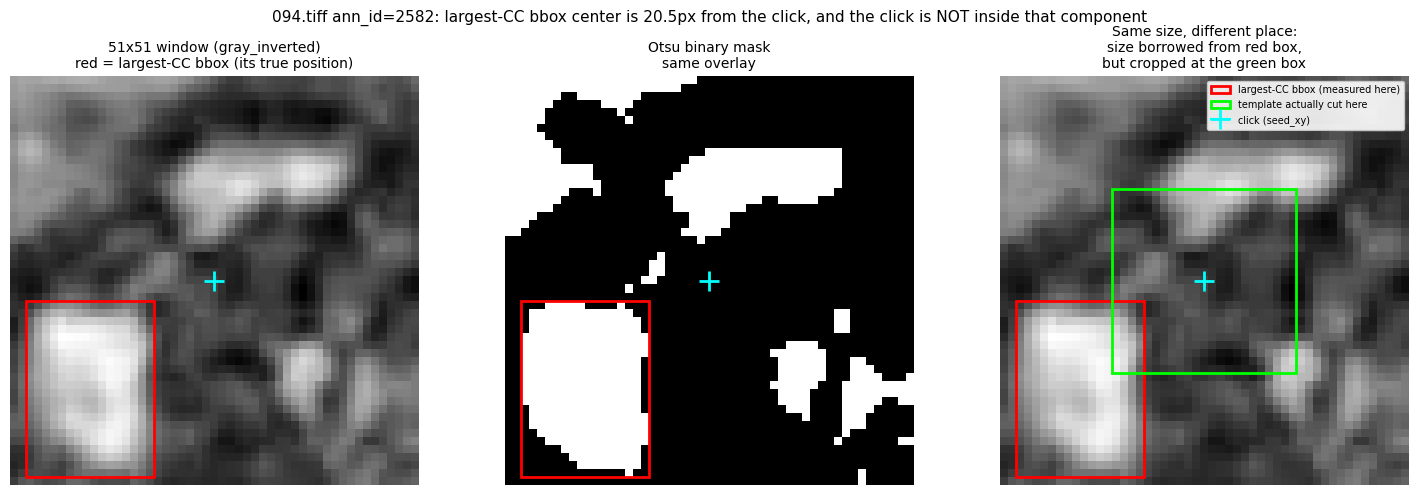

In [4]:
half_t = base_size / 2.0
lcc_box_xy = (x0 - 0.5, y0 - 0.5, x1 - x0, y1 - y0)          # where Otsu's largest CC actually is
template_box_xy = (c - half_t, c - half_t, base_size, base_size)  # where the template is actually cut from

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, img, title in zip(
    axes[:2],
    [patch51, binary],
    ['51x51 window (gray_inverted)\nred = largest-CC bbox (its true position)',
     'Otsu binary mask\nsame overlay'],
):
    ax.imshow(img, cmap='gray')
    ax.add_patch(mpatches.Rectangle(lcc_box_xy[:2], lcc_box_xy[2], lcc_box_xy[3],
                                     edgecolor='red', facecolor='none', linewidth=2))
    ax.plot(c, c, marker='+', color='cyan', markersize=14, markeredgewidth=2)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

ax = axes[2]
ax.imshow(patch51, cmap='gray')
ax.add_patch(mpatches.Rectangle(lcc_box_xy[:2], lcc_box_xy[2], lcc_box_xy[3],
                                 edgecolor='red', facecolor='none', linewidth=2, label='largest-CC bbox (measured here)'))
ax.add_patch(mpatches.Rectangle(template_box_xy[:2], template_box_xy[2], template_box_xy[3],
                                 edgecolor='lime', facecolor='none', linewidth=2, label='template actually cut here'))
ax.plot(c, c, marker='+', color='cyan', markersize=14, markeredgewidth=2, label='click (seed_xy)')
ax.set_title('Same size, different place:\nsize borrowed from red box,\nbut cropped at the green box', fontsize=10)
ax.legend(loc='upper right', fontsize=7, framealpha=0.9)
ax.axis('off')

fig.suptitle(f'{FN} ann_id={ANN_ID}: largest-CC bbox center is {np.hypot((y0+y1)/2-c, (x0+x1)/2-c):.1f}px '
             f'from the click, and the click is {"inside" if click_in_lcc else "NOT inside"} that component',
             fontsize=11)
plt.tight_layout()
plt.savefig('lcc_offset_demo.png', dpi=150, bbox_inches='tight')
plt.show()

## Context: the raw annotation, and a wider view of its ROI

The 51x51 window above is a small fraction of the tissue. Here's the actual MIDOG++ ground-truth
box (`dataset.BOX_SIZE = 50`, this repo's usual red = mitotic / yellow = look-alike convention from
`midog_utils.viz`), a moderate crop around it, and where that crop sits inside the full 5364x7103 ROI.

Checked: no other GT annotation (of either category) falls within 175 px of this click, so the
competing largest-CC blob is not itself a labelled structure -- just an unannotated, high-contrast
nucleus that happens to threshold larger than the true object.

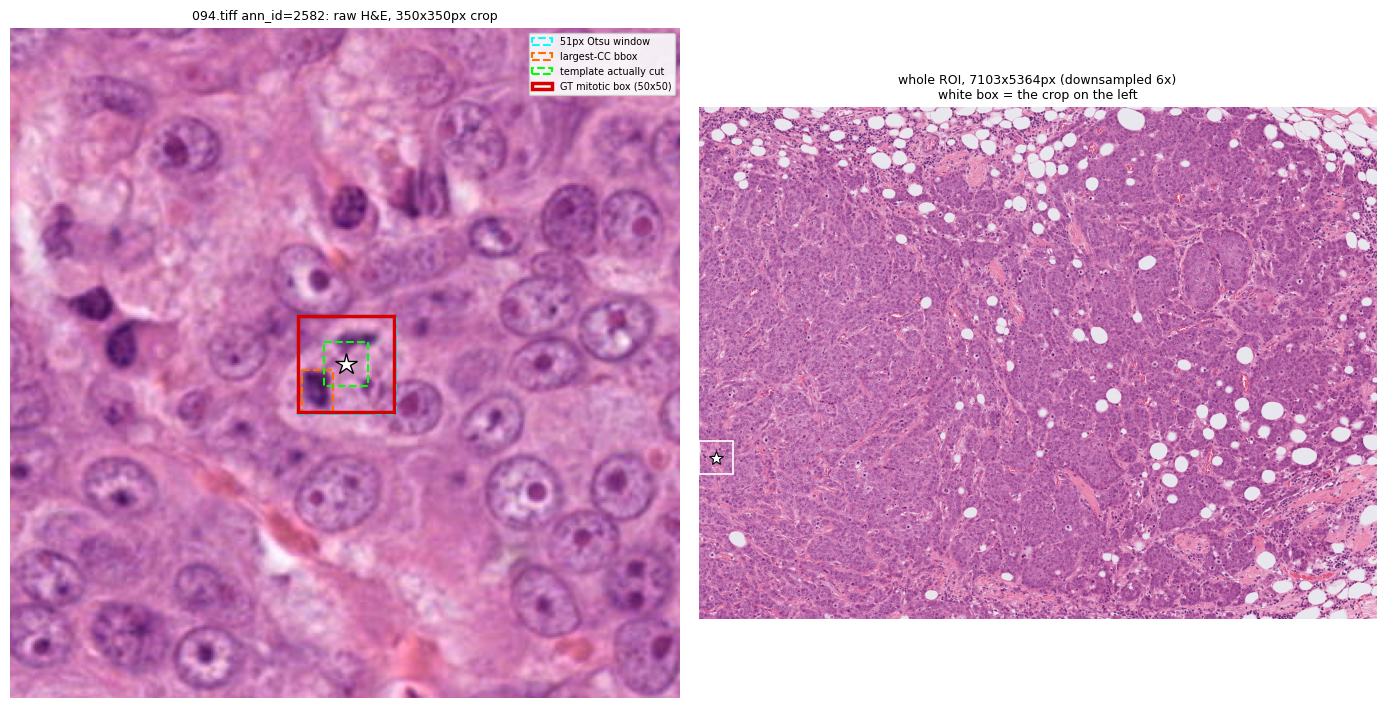

In [5]:
ix, iy = int(round(cx)), int(round(cy))

def to_global(y0, y1, x0, x1, half=OTSU_WINDOW // 2):
    """51x51-patch-local box coords -> full-ROI pixel coords."""
    return (ix - half + x0, iy - half + y0, x1 - x0, y1 - y0)

otsu_win_g = (ix - c, iy - c, OTSU_WINDOW, OTSU_WINDOW)
lcc_g = to_global(y0, y1, x0, x1)
template_g = (cx - half_t, cy - half_t, base_size, base_size)

BOX_SIZE = 50  # dataset.BOX_SIZE -- every MIDOG++ annotation box

def draw_gt_boxes(ax, gt_df, x0, y0):
    # zorder=10 and a thick solid line so this box stays visible even though it's almost
    # exactly the same extent as the (dashed) 51px Otsu window drawn after it.
    for _, a in gt_df.iterrows():
        color = '#d50000' if a['category_id'] == 1 else '#ffea00'
        ax.add_patch(mpatches.Rectangle(
            (a['cx'] - BOX_SIZE / 2 - x0, a['cy'] - BOX_SIZE / 2 - y0), BOX_SIZE, BOX_SIZE,
            fill=False, edgecolor=color, linewidth=2.5, zorder=10))

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# --- moderate crop: ~350x350, raw RGB, with the GT box and the three earlier boxes ---
half_crop = 175
cx0, cy0 = max(0, ix - half_crop), max(0, iy - half_crop)
cx1, cy1 = min(roi_w, ix + half_crop), min(roi_h, iy + half_crop)
crop = rgb[cy0:cy1, cx0:cx1]

ax = axes[0]
ax.imshow(crop)
draw_gt_boxes(ax, gt[(gt['cx'].between(cx0 - 30, cx1 + 30)) & (gt['cy'].between(cy0 - 30, cy1 + 30))], cx0, cy0)
# 'largest-CC bbox' is orange, not red, so it can't be mistaken for the red = GT-mitotic convention.
for box, color, label in [(otsu_win_g, 'cyan', '51px Otsu window'),
                          (lcc_g, '#ff6d00', 'largest-CC bbox'),
                          (template_g, 'lime', 'template actually cut')]:
    bx, by, bw, bh = box
    ax.add_patch(mpatches.Rectangle((bx - cx0, by - cy0), bw, bh, fill=False,
                                     edgecolor=color, linewidth=1.5, linestyle='--', label=label, zorder=6))
ax.plot(cx - cx0, cy - cy0, marker='*', markersize=16, color='white', markeredgecolor='black',
        markeredgewidth=1, zorder=11)

gt_handle = mpatches.Patch(edgecolor='#d50000', facecolor='none', linewidth=2.5, label='GT mitotic box (50x50)')
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles=handles + [gt_handle], loc='upper right', fontsize=7, framealpha=0.9)
ax.set_title(f'{FN} ann_id={ANN_ID}: raw H&E, {cx1-cx0}x{cy1-cy0}px crop', fontsize=9)
ax.axis('off')

# --- whole-ROI orientation thumbnail, downsampled, with the crop region marked ---
ds_factor = 6
thumb = rgb[::ds_factor, ::ds_factor]
ax = axes[1]
ax.imshow(thumb)
ax.add_patch(mpatches.Rectangle((cx0 / ds_factor, cy0 / ds_factor), (cx1 - cx0) / ds_factor, (cy1 - cy0) / ds_factor,
                                 fill=False, edgecolor='white', linewidth=1.2))
ax.plot(cx / ds_factor, cy / ds_factor, marker='*', markersize=10, color='white', markeredgecolor='black', markeredgewidth=0.8)
ax.set_title(f'whole ROI, {roi_w}x{roi_h}px (downsampled {ds_factor}x)\nwhite box = the crop on the left', fontsize=9)
ax.axis('off')

plt.tight_layout()
plt.savefig('lcc_offset_demo_context.png', dpi=150, bbox_inches='tight')
plt.show()

## Follow-up: how big is the recentering effect under the *production* gate?

The example above uses the permissive rule (`largest_cc_box`, no containment check) used by the
`precision_at_k_budgets_14roi*` notebooks -- and 094.tiff ann 2582 would in fact be **refused**
under the production rule below, since the click sits outside its own largest component.

`midog_utils.seed_selection.tighten_box_otsu` is stricter: it only accepts the connected
component the click's own pixel (or a pixel within `center_tolerance`) actually lands in. That
gate stays exactly as-is (DECISIONS.md D8 keeps it). What's being decided is what happens to the
box **after** that gate passes: today it's resized but kept centred on the raw click; D8 also
recenters it onto the accepted component's own bbox center.

This cell measures how far that recentering actually moves things, over the same 14-ROI,
unanimous, border-filtered mitotic population as the audit above.

In [6]:
import pandas as pd
from midog_utils import seed_selection as ss

rows = []
for fn2 in sorted(f for f in __import__('os').listdir('../images/extra_valid') if f.endswith('.tiff')):
    rgb2 = ds.load_roi(f'../images/extra_valid/{fn2}')
    gray_inv2 = ch.to_gray_inverted(rgb2)
    gt2 = ds.image_annotations(annotations, fn2)
    mitotic2 = gt2[gt2['category_id'] == ds.MITOTIC]
    pool2, _ = ss.agreement_pool(mitotic2)
    pool2 = ss.border_filter(pool2, tm.PATCH_SIZE // 2, rgb2.shape)

    for _, r2 in pool2.iterrows():
        cx2, cy2 = float(r2['cx']), float(r2['cy'])
        p2 = tm.read_padded_patch(gray_inv2, cx2, cy2, OTSU_WINDOW)
        if p2 is None:
            continue
        box2 = ss.tighten_box_otsu(p2)  # the actual production gate: click must be in-component
        if box2 is None:
            rows.append(dict(file_name=fn2, ann_id=int(r2['ann_id']), gated_ok=False, offset=np.nan))
            continue
        yy0, yy1, xx0, xx1 = box2
        cc = OTSU_WINDOW / 2.0
        off = float(np.hypot((yy0 + yy1) / 2.0 - cc, (xx0 + xx1) / 2.0 - cc))
        rows.append(dict(file_name=fn2, ann_id=int(r2['ann_id']), gated_ok=True, offset=off))

G = pd.DataFrame(rows)
ok2 = G[G['gated_ok']]
print(f'{len(G)} unanimous, border-ok mitotic annotations scanned across 14 ROIs')
print(f'tighten_box_otsu (production gate) accepts: {len(ok2)}/{len(G)} ({100*len(ok2)/len(G):.1f}%)')
print()
print("Among accepted seeds, offset between the raw click and the accepted component's own bbox center:")
print(ok2['offset'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).round(2))
print(f"\nfraction with offset > 2px: {(ok2['offset'] > 2).mean():.3f}")
print(f"fraction with offset > 5px: {(ok2['offset'] > 5).mean():.3f}")
print(f"fraction with offset > 10px: {(ok2['offset'] > 10).mean():.3f}")

993 unanimous, border-ok mitotic annotations scanned across 14 ROIs
tighten_box_otsu (production gate) accepts: 896/993 (90.2%)

Among accepted seeds, offset between the raw click and the accepted component's own bbox center:
count    896.00
mean       3.47
std        2.38
min        0.00
50%        3.10
75%        4.74
90%        6.76
95%        8.14
99%       10.63
max       13.87
Name: offset, dtype: float64

fraction with offset > 2px: 0.708
fraction with offset > 5px: 0.215
fraction with offset > 10px: 0.016
